# SatIQ Plots: Data

This notebook is used to generate all the "data" plots (samples, distribution of IDs, etc) in the "SatIQ" paper.

## Setup

In [ ]:
plot_dir = "../plots/data"
data_base = "../data/"
fig_width = 12.0 # Width of a figure that spans 100% of the page width
fig_height = 8.0 # Height of a figure that spans 100% of the page width
def fig_size(scale=1.0, height=1.0, square=False):
    if not square:
        return (fig_width * scale, fig_height * scale * height)
    else:
        return (fig_width * scale, fig_width * scale)

In [10]:
import os
import datetime
import functools
import numpy as np
import pandas as pd
import tensorflow as tf
from tqdm import tqdm
import json
import pickle
import re

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import seaborn as sns
import colorsys
import matplotlib.colors as mcolors

import ast
tqdm.pandas()

from util.data import TFRecordLoaderFull

In [11]:
def get_palette():
    colors = [
        (190, 15, 52),
        (72, 145, 220),
        (0, 119, 112),
    ]
    colors += [ (int(r*256), int(g*256), int(b*256)) for r, g, b in sns.color_palette('colorblind')[len(colors):] ]
    colors_hex = [f'#{r:02x}{g:02x}{b:02x}' for r, g, b in colors]

    return colors_hex

def get_palette_gradient(ref):
    if ref == "fingerprinting":
        hls_start = [ colorsys.rgb_to_hls(*color) for color in sns.color_palette("rocket", as_cmap=False, n_colors=256) ]
        hue_shift = colorsys.rgb_to_hls(*[ c / 255 for c in (190, 15, 52) ])[0] - hls_start[130][0]
        colors_shifted = [ colorsys.hls_to_rgb((hue + hue_shift) % 1, l, s) for (hue, l, s) in hls_start ]
        palette_gradient = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors_shifted)
    elif ref == "fingerprinting_2":
        colors_gradient = [f'#{r:02x}{g:02x}{b:02x}' for r, g, b in
            [
                (235, 196, 203),
                (190, 15, 52),
                (135, 36, 52)
            ]
        ]
        colors_gradient_str = ','.join(colors_gradient)
        palette_gradient = sns.color_palette(f"blend:{colors_gradient_str}", as_cmap=True)
    elif ref == "fingerprinting_3":
        colors_gradient = [f'#{r:02x}{g:02x}{b:02x}' for r, g, b in
            [
                (235, 196, 203),
                (190, 15, 52),
                (135, 36, 52)
            ]
        ]
        colors_gradient_str = ','.join(colors_gradient)
        palette_gradient = sns.color_palette(f"blend:#ffffff,{colors_gradient_str}", as_cmap=True)
    else:
        raise ValueError(f"Unknown reference: {ref}")

    return palette_gradient

sns.set_theme(palette=get_palette(), color_codes=True)
palette_gradient = get_palette_gradient("fingerprinting")

sns.set_style('ticks')
sns.set_context('notebook', font_scale=1.3)
plt.rcParams['figure.dpi'] = 72
#plt.rcParams['font.family'] = 'DejaVu Sans'

plt.rcParams['font.family'] = 'serif' # or 'sans-serif' or 'monospace'
plt.rcParams['font.serif'] = 'cmr10'
plt.rcParams['font.sans-serif'] = 'cmss10'
plt.rcParams['font.monospace'] = 'cmtt10'
plt.rcParams["axes.formatter.use_mathtext"] = True # to fix the minus signs

sns.color_palette(get_palette())

[(0.7450980392156863, 0.058823529411764705, 0.20392156862745098),
 (0.2823529411764706, 0.5686274509803921, 0.8627450980392157),
 (0.0, 0.4666666666666667, 0.4392156862745098),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [12]:
# Decorator to add optional output_pdf and show arguments to plot functions
def plot_d(func, save_dir):
    @functools.wraps(func)
    def wrapper(*args, output_pdf=None, dpi=None, show=True, **kwargs):
        res = func(*args, **kwargs)

        if output_pdf is not None:
            if dpi is None:
                plt.savefig(os.path.join(save_dir, output_pdf), bbox_inches='tight')
            else:
                plt.savefig(os.path.join(save_dir, output_pdf), bbox_inches='tight', dpi=dpi)
        if show:
            plt.show()
        plt.close()

        return res

    return wrapper

os.makedirs(plot_dir, exist_ok=True)
plot = functools.partial(plot_d, save_dir=plot_dir)

In [21]:
data_dir = os.path.join(data_base, "tfrecord")
label_dir = os.path.join(data_base, "test", "labels")
results_dir = os.path.join(data_base, "results")

## sample.pdf

In [7]:
ds = TFRecordLoaderFull.from_file(os.path.join(data_dir, "2023-05-12_0.tfrecord"), all_features=False, shuffle=False)

2025-09-03 15:49:41.745798: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-03 15:49:42.187958: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1525] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22808 MB memory:  -> device: 0, name: NVIDIA TITAN RTX, pci bus id: 0000:82:00.0, compute capability: 7.5


In [8]:
# Grab a batch of data to use for plotting
samples = np.array([ d[0] for d in ds ])
labels = np.array([ d[1] for d in ds ])

In [14]:
# Plot a single sample
@plot
def plot_sample(sample, size=0.8, height=0.76):
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=fig_size(size, height))
    ax = axs[0]
    x = np.arange(sample.shape[0], dtype=np.float64)
    print(x.shape)
    x /= 25000000
    x *= 1e3
    ax.plot(x, sample[:,0], label='Real')
    ax.plot(x, sample[:,1], label='Imaginary')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Amplitude')
    ax.legend(loc='upper left')
    ax = axs[1]
    ax.plot(sample[:,0], sample[:,1])
    ax.set_xlabel('Amplitude (Real)')
    ax.set_ylabel('Amplitude (Imaginary)')

    plt.tight_layout()

(11000,)


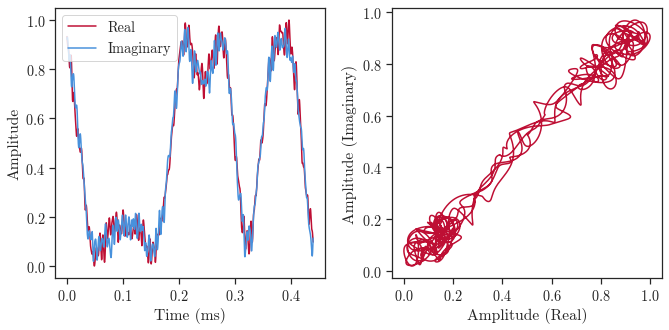

In [15]:
plot_sample(samples[1], output_pdf="sample.pdf")

## dataset-timeline.pdf

In [17]:
def load_labels(label_dir, verbose=True):
    labels = []
    label_files = [ f for f in os.listdir(label_dir) if f.endswith('_0.npy') ]
    label_files.sort()
    for f in label_files:
        labels.append(np.load(os.path.join(label_dir, f)))

    labels = np.array(labels)
    return labels

labels = load_labels(label_dir, verbose=True)
labels = labels.flatten()
labels

array([5208, 5379, 5200, ..., 2938,  569, 2938])

In [18]:
@plot
def plot_distribution(labels_array, discrete, size=1.0):
    id_counts = np.sort(np.unique(labels_array, return_counts=True)[1])

    fig, ax = plt.subplots(figsize=fig_size(size))

    if discrete:
        sns.histplot(id_counts, discrete=True, ax=ax)
    else:
        sns.histplot(id_counts, binwidth=32, ax=ax)
    ax.set_yscale('log')
    ax.set(xlabel='Number of Messages', ylabel='Number of Transmitters')

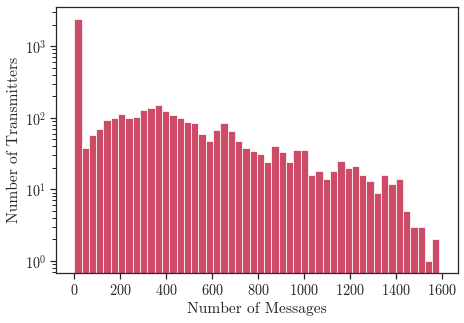

In [19]:
plot_distribution(labels, False, size=0.6, output_pdf="iridium-histogram.pdf")

## dataset-timeline.pdf

In [30]:
def compute_timestamps(tfrecord_files, verbose=True, days=False, start_date=None, kind='mean'):
    timestamps = []

    for tfrecord_file in tqdm(tfrecord_files, disable=not verbose):
        ds_t = TFRecordLoaderFull.from_file(os.path.join(data_dir, tfrecord_file), all_features=True, shuffle=False)

        if kind == 'mean':
            timestamp = np.array([ ts for ts in ds_t.map(lambda x: x['timestamp']) ]).mean()
        elif kind == 'min':
            timestamp = np.array([ ts for ts in ds_t.map(lambda x: x['timestamp']) ]).min()
        elif kind == 'max':
            timestamp = np.array([ ts for ts in ds_t.map(lambda x: x['timestamp']) ]).max()
        else:
            raise ValueError(f"Unknown kind: {kind}")

        timestamps.append(timestamp)

        del ds_t

    if days:
        if start_date is not None:
            index_start = tfrecord_files.index([ f for f in tfrecord_files if start_date in f ][0])
            timestamp_start = timestamps[index_start]
            return (np.array(timestamps) - timestamp_start) / (1e9 * 24 * 60 * 60)
        else:
            raise ValueError('start_date must be provided if days is True')
    else:
        return timestamps

In [38]:
tfrecord_files_all = {}
timestamps_all = {}
#for name, loc, filter_zero in [('UK', '', True), ('UK (Old)', 'old', False), ('Germany', 'germany', False), ('Switzerland', 'switzerland', True)]:
for name, loc, filter_zero in [('UK', '', True), ('Germany', 'germany', False), ('Switzerland', 'switzerland', True)]:
    tfrecord_files_all[name] = [ os.path.join(loc, f) for f in os.listdir(os.path.join(data_dir, loc)) if (not filter_zero) or f.endswith('_0.tfrecord') ]
    tfrecord_files_all[name].sort()

    timestamps = compute_timestamps(tfrecord_files_all[name], verbose=True)
    timestamps = np.array(timestamps)
    timestamps = np.sort(timestamps)
    timestamps_all[name] = [ datetime.datetime.fromtimestamp(ts / 1e9) for ts in timestamps ]

  0%|          | 0/253 [00:00<?, ?it/s]

100%|██████████| 22/22 [00:13<00:00,  1.65it/s]


In [10]:
# We need to handle Germany separately
timestamps_de = []
for tfrecord_file in tqdm([ os.path.join('germany', f) for f in os.listdir(os.path.join(data_dir, 'germany')) ]):
    ds_t = TFRecordLoaderFull.from_file(os.path.join(data_dir, tfrecord_file), all_features=True, shuffle=False)
    timestamps_de.extend([ ts for ts in ds_t.map(lambda x: x['timestamp']) ])
    del ds_t
timestamps_de = np.array(timestamps_de)
timestamps_de = np.sort(timestamps_de)
timestamps_de = [ datetime.datetime.fromtimestamp(ts / 1e9) for ts in timestamps_de ]
timestamps_all['Germany'] = timestamps_de

100%|██████████| 29/29 [00:12<00:00,  2.36it/s]


In [32]:
timestamp_boundaries = {}

for name, timestamps in timestamps_all.items():
    ts_b = [ timestamps[0] ]
    for i in range(len(timestamps) - 1):
        if timestamps[i+1] - timestamps[i] > datetime.timedelta(days=2):
            ts_b.append(timestamps[i])
            ts_b.append(timestamps[i+1])
    ts_b.append(timestamps[-1])

    timestamp_boundaries[name] = ts_b

In [19]:
# Save timestamp_boundaries
with open(os.path.join(results_dir, 'timestamp_boundaries.json'), 'w') as f:
    json.dump(timestamp_boundaries, f, default=str)

In [22]:
# Load timestamp_boundaries
with open(os.path.join(results_dir, 'timestamp_boundaries.json'), 'r') as f:
    timestamp_boundaries = json.load(f)

# Convert to datetime objects
for name, ts_b in timestamp_boundaries.items():
    timestamp_boundaries[name] = [ datetime.datetime.fromisoformat(ts) for ts in ts_b ]

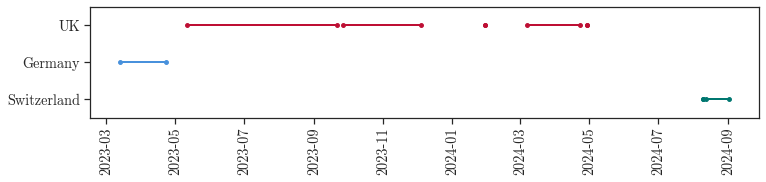

In [23]:
@plot
def plot_timeline(boundaries, names, size=1.0, height=0.25):
    fig, ax = plt.subplots(figsize=fig_size(size, height))

    for i in range(0, len(boundaries)):
        color = sns.color_palette()[len(boundaries) - 1 - i]

        plt.scatter(boundaries[i], [ i for _ in range(len(boundaries[i])) ], color=color, s=15)

        for j in range(0, len(boundaries[i]), 2):
            ax.plot([boundaries[i][j], boundaries[i][j+1]], [i, i], color=color, linewidth=2)

    ax.set_ylim(-0.5, len(boundaries)-0.5)

    plt.yticks(list(range(len(boundaries))), names)

    plt.xticks(rotation=90)

names, boundaries = zip(*reversed(timestamp_boundaries.items()))
plot_timeline(boundaries, names, output_pdf="dataset-timeline.pdf")

In [35]:
# Compute "days active" for each dataset
for name, timestamps in timestamp_boundaries.items():
    print(name)
    total = datetime.timedelta()
    for i in range(0, len(timestamps), 2):
        print(f"  {timestamps[i]} - {timestamps[i+1]}")
        total += timestamps[i+1] - timestamps[i]
    print(f"  Total: {total}")

UK
  2023-05-11 15:19:43.273189 - 2023-09-20 19:13:09.434077
  2023-09-26 12:30:34.857982 - 2023-12-04 14:00:44.867222
  2024-01-29 16:20:05.147461 - 2024-01-29 16:20:05.147461
  2024-03-06 18:14:29.577252 - 2024-04-22 19:04:49.379256
  2024-04-29 10:42:24.675574 - 2024-04-29 10:42:24.675574
  Total: 248 days, 6:13:55.972132
Germany
  2023-03-13 11:10:19.446320 - 2023-04-23 01:37:41.639049
  Total: 40 days, 14:27:22.192729
Switzerland
  2024-08-09 18:11:59.045688 - 2024-08-09 18:11:59.045688
  2024-08-12 12:52:53.810434 - 2024-09-01 11:15:14.666581
  Total: 19 days, 22:22:20.856147


In [36]:
for name, timestamps in timestamps_all.items():
    print(f"{name}: Start {timestamps[0].date()}, End {timestamps[-1].date()}")

In [37]:
print("Messages collected:")
for name, loc in [('UK', ''), ('Germany', 'germany'), ('Switzerland', 'switzerland')]:
    tfrecord_files = [ f for f in os.listdir(os.path.join(data_dir, loc)) ]
    print(f'  {name}: {len(tfrecord_files) * 5000}')

Messages collected:
  UK: 9710000
  Germany: 145000
  Switzerland: 450000
